## Ejercicio 2  

Utilice para **entrenamiento** y **prueba** los conjuntos de datos `concent_trn.csv` y `concent_tst.csv`, que consisten en dos clases distribuidas en forma **concéntrica** como muestra la Figura 1.  
Determine la **estructura de una red de tipo perceptrón multicapa** que resulte más apropiada para resolver este problema.  
Represente gráficamente, con diferentes colores, el resultado de la **clasificación realizada por el perceptrón multicapa**.  


### Importaciones

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from PerceptronSimple import PerceptronSimple


### Definición de la estructura de la red neuronal

En este bloque se especifica la **topología de la red neuronal multicapa** mediante el vector `estructura`:  

- `estructura = np.array([2, 2, 1])`  
  - **2** → Número de **entradas** (sin contar el sesgo).  
  - **2** → Número de **neuronas en la capa oculta**.  
  - **1** → Número de **neuronas de salida**.  

A partir de esto se calculan:  
- `cant_capas = len(estructura) - 1` → Número de capas con pesos entrenables (ocultas + salida).  
- `cant_salidas = estructura[-1]` → Número de salidas de la red (último valor del vector).  


In [2]:
estructura = np.array([2, 3, 1])
cant_capas = len(estructura) - 1
cant_salidas = estructura[-1]

### Cargamos los datos


In [3]:
def load_data(path): 
  
  data = np.loadtxt(path, delimiter=",")
  cant_entradas = estructura[0]

  X = data[:, :cant_entradas]
  y = data[:, -1]

  X = np.hstack(( -np.ones((X.shape[0], 1)), X ))

  return X, y

In [4]:
X_train, Y_train = load_data("./data/concent_trn.csv")
#print(X_train)

In [5]:
def init_weights(): 
  w = []

  for i in range(cant_capas): 
    n_neuronas = estructura[i+1]
    n_entradas = estructura[i] + 1 # Sumo uno por el bias
    w_aux = np.random.rand( n_neuronas, n_entradas)-0.5
    w.append(w_aux)

  return w
w = init_weights()
#print(w)

In [6]:
def sigmoidea(v):
    return ((2/(1+np.exp(-v)))-1)

def d_sigmoidea(y):
    return ((1+y)*(1-y))

y = np.empty(cant_capas, dtype=object)
delta = np.empty(cant_capas, dtype=object)

### Propagacion hacia delante

In [7]:
def forward_prop(entradas):
  #entradas = X_train[patron]
  for capa in range(cant_capas): 
      # Salida lineal
      z = np.dot(w[capa], entradas)
      # Salida no lineal
      y[capa] = sigmoidea(z)
      entradas = np.hstack(([-1], y[capa]))
  return y

### Propagacion hacia atras

In [8]:
def back_prop(y_deseada, y): 
  e = y_deseada - y[-1]
  delta[-1] = e * 1/2 * d_sigmoidea(y[-1])

  for i in range(cant_capas - 1, 0, -1): 
    w_i = w[i][:, 1:].T # Elimino la col del bias
    d = np.dot(w_i, delta[i])
    delta[i-1] = d*(1/2)*d_sigmoidea(y[i-1])

  return delta

### Actualizacion de pesos

In [9]:
def actualizacion(patron, delta, tasa): 
  entradas = X_train[patron]
  for capa in range(cant_capas): 
    delta_peso = tasa * np.outer(delta[capa], entradas)
    w[capa] += delta_peso

    entradas = np.hstack(([-1], y[capa]))

  return w

## Entrenamiento

In [10]:
# Hiperparámetros
epocas = 2000
tasa_aprendizaje = 0.01
perc_error_max = 0.01   # Tolerancia máxima de error (10%)

# Métricas por época
errores_por_epoca = []
mse_por_epoca = []

# Entrenamiento
for epoca in range(epocas): 
    # Fase de entrenamiento (forward + backprop + actualización)
    for patron in range(len(X_train)):
        y_d = Y_train[patron]
        y = forward_prop(X_train[patron])                     # Propagación hacia adelante
        delta = back_prop(y_d, y)                    # Retropropagación del error
        w = actualizacion(patron, delta, tasa_aprendizaje)  # Actualización de pesos
        # print(w)
    # Evaluación del desempeño
    errores = 0     # Cantidad de predicciones incorrectas
    cont_mse = 0.0  # Error cuadratico medio sobre todos los patrones  

    for patron in range(len(X_train)):
        
        y = forward_prop(X_train[patron])

        yc = np.sign(y[-1])  # Clasificación final

        if (Y_train[patron] != yc).any(): 
            errores += 1
        
        cont_mse += np.sum(np.square(Y_train[patron] - y[-1]))

    # Guardar métricas
    # Calculamos el error cuadratico medio promedio
    mse = cont_mse / len(X_train)
    mse_por_epoca.append(mse)

    perc_error = errores / len(X_train)
    errores_por_epoca.append(perc_error)

    # Porcentaje de acierto obtenido
    acierto = 100 * (1 - perc_error)

    # Criterio de parada por convergencia
    if perc_error < perc_error_max: 
        print("🟢 Finalizado por convergencia (error < perc_error_max)")
        break
else:
    print("🔁 Finalizado por límite de épocas")
    print(f"Época {epoca+1}/{epocas} → Errores: {errores}/{len(X_train)} | Acierto: {acierto:.2f}% | MSE: {mse:.6f}")


🟢 Finalizado por convergencia (error < perc_error_max)


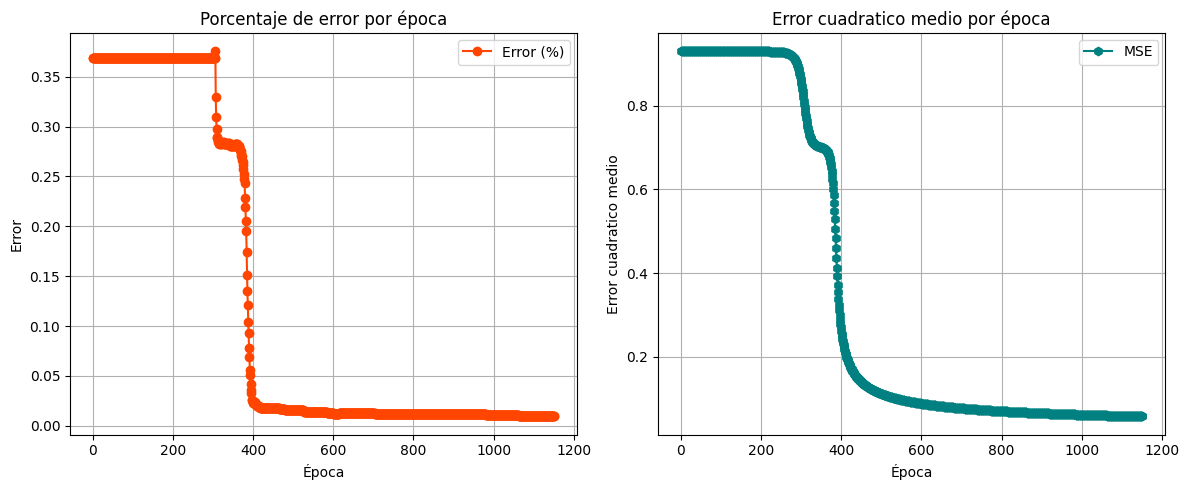

In [11]:
epocas = range(1, len(errores_por_epoca) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de errores
ax[0].plot(epocas, errores_por_epoca, marker='o', color='orangered', label='Error (%)')
ax[0].set_title('Porcentaje de error por época')
ax[0].set_xlabel('Época')
ax[0].set_ylabel('Error')
ax[0].grid(True)
ax[0].legend()

# Gráfico de MSE
ax[1].plot(epocas, mse_por_epoca, marker='h', color='teal', label='MSE')
ax[1].set_title('Error cuadratico medio por época')
ax[1].set_xlabel('Época')
ax[1].set_ylabel('Error cuadratico medio')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

## Testeo

In [12]:
X_tst, Y_tst = load_data("./data/concent_tst.csv")

errores = 0

salidas_capa_oculta = []
y_saved = []

for patron in range (len(X_tst)): 
  y = forward_prop(X_tst[patron])
  yc = np.sign(y[-1])
  if((Y_tst[patron] != yc).any()): errores += 1

  salidas_capa_oculta.append(np.sign(y[0]))
  y_saved.append(yc)


acierto = (1-errores/len(X_tst))*100
print("El Test finalizo con: ", errores, "/", len(X_tst), " errores ")
print("Tasa de acierto: ", round(acierto,2),'%')


El Test finalizo con:  13 / 1000  errores 
Tasa de acierto:  98.7 %


In [47]:
print(w)
print(y_saved)

[array([[ -8.79119408, -13.62084939,   1.11477806],
       [ -7.08322334,  -7.27191583, -11.89917056],
       [ -5.23560967,   5.9948861 , -12.06631041]]), array([[-20.05944896, -15.45384547,  15.44822396, -15.54963529]])]
[array([1.]), array([1.]), array([1.]), array([1.]), array([1.]), array([-1.]), array([-1.]), array([-1.]), array([1.]), array([-1.]), array([1.]), array([1.]), array([1.]), array([-1.]), array([-1.]), array([1.]), array([-1.]), array([-1.]), array([1.]), array([-1.]), array([1.]), array([-1.]), array([1.]), array([1.]), array([1.]), array([1.]), array([1.]), array([-1.]), array([1.]), array([1.]), array([1.]), array([1.]), array([1.]), array([1.]), array([1.]), array([-1.]), array([1.]), array([1.]), array([1.]), array([1.]), array([-1.]), array([1.]), array([1.]), array([1.]), array([1.]), array([-1.]), array([1.]), array([1.]), array([-1.]), array([1.]), array([1.]), array([1.]), array([-1.]), array([1.]), array([1.]), array([-1.]), array([-1.]), array([-1.]), arr

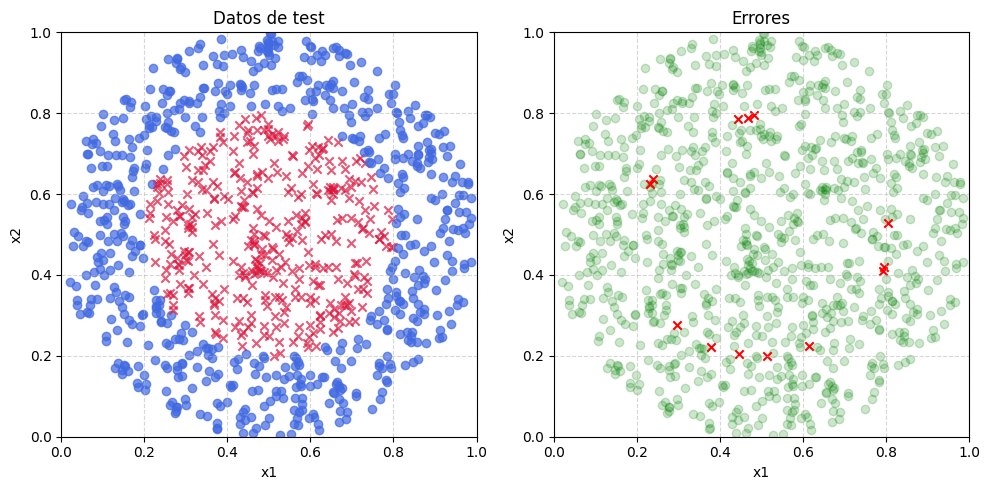

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for i in range(len(Y_tst)):
  if Y_tst[i] == 1:
    axs[0].scatter(X_tst[i, 1], X_tst[i, 2], color="royalblue", marker="o", alpha=0.7) 
  else: 
    axs[0].scatter(X_tst[i, 1], X_tst[i, 2],color="crimson", marker="x", alpha=0.7)

for i in range(len(Y_tst)): 
  if Y_tst[i] == y_saved[i]: 
    axs[1].scatter(X_tst[i, 1], X_tst[i, 2], color="green", marker="o", alpha=0.2) 
  else: 
    axs[1].scatter(X_tst[i, 1], X_tst[i, 2], color="red", marker="x", alpha=1) 



axs[0].set_title("Datos de test")
axs[0].set_xlabel("x1")
axs[0].set_ylabel("x2")
axs[0].grid(True, linestyle="--", alpha=0.5)
axs[0].set_xlim(0, 1)   
axs[0].set_ylim(0, 1)


axs[1].set_title("Errores")
axs[1].set_xlabel("x1")
axs[1].set_ylabel("x2")
axs[1].grid(True, linestyle="--", alpha=0.5)
axs[1].set_xlim(0, 1)   
axs[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()
